# 10 SHAP Model Comparison

This notebook compares SHAP feature importance across the three main XGBoost models from the business-threshold analysis.

The simplified regularized models from notebook 09 are not included here because they reduced the train-validation gap but did not improve validation performance.


## Setup

Keep the same full-data time split and the same `v2_full` feature set used in notebooks 08 and 09.

Models compared:

- `v2_full_reference`: original `v2_full` XGBoost reference
- `tuned_params_no_class_weight`: tuned hyperparameters without extra fraud-class weighting
- `tuned_cost_sensitive_xgb`: same tuned hyperparameters with fraud-class weighting


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from xgboost import XGBClassifier
import shap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.data_prep_safe import load_merged_data_safe, make_time_validation_split
from src.fraud_detection.eda import set_plot_theme
from src.fraud_detection.metrics import compute_classification_metrics
from src.fraud_detection.tree_preprocessing_v2 import fit_tree_preprocessor_v2, transform_tree_preprocessor_v2

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 1_600
SHAP_FRAUD_ROWS = 500
TOP_N = 15

MODEL_COLORS = {
    "v2_full_reference": "#2563eb",
    "tuned_params_no_class_weight": "#64748b",
    "tuned_cost_sensitive_xgb": "#dc2626",
}
MODEL_ORDER = ["v2_full_reference", "tuned_params_no_class_weight", "tuned_cost_sensitive_xgb"]

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "shap_model_comparison_summary.json"


## Data And `v2_full` Features


In [2]:
train_df, test_df = load_merged_data_safe(nrows=None)
train_part, valid_part = make_time_validation_split(train_df)

artifacts = fit_tree_preprocessor_v2(
    train_part,
    add_missing_indicators=True,
    add_group_amount_features=True,
    drop_missing_threshold=0.999,
)

x_train = transform_tree_preprocessor_v2(train_part, artifacts, impute_numeric=False)
x_valid = transform_tree_preprocessor_v2(valid_part, artifacts, impute_numeric=False)
y_train = train_part["isFraud"].to_numpy()
y_valid = valid_part["isFraud"].to_numpy()

positive_count = int(y_train.sum())
negative_count = int(len(y_train) - positive_count)
base_scale_pos_weight = negative_count / max(1, positive_count)

data_summary = pd.DataFrame(
    [
        ["labelled_rows", len(train_df)],
        ["time_split_train_rows", len(train_part)],
        ["time_split_validation_rows", len(valid_part)],
        ["train_fraud_rate", y_train.mean()],
        ["validation_fraud_rate", y_valid.mean()],
        ["v2_full_feature_count", x_train.shape[1]],
        ["base_scale_pos_weight", base_scale_pos_weight],
    ],
    columns=["item", "value"],
)
display(data_summary.style.hide(axis="index"))


item,value
labelled_rows,590540.000000
time_split_train_rows,472432.000000
time_split_validation_rows,118108.000000
train_fraud_rate,0.035135
validation_fraud_rate,0.034409
v2_full_feature_count,807.000000
base_scale_pos_weight,27.461474


## Fit The Three Main Models


In [3]:
def make_xgb(params):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )


model_configs = {
    "v2_full_reference": {
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
    },
    "tuned_params_no_class_weight": {
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 3,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "scale_pos_weight": 1.0,
    },
    "tuned_cost_sensitive_xgb": {
        "n_estimators": 700,
        "max_depth": 8,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "min_child_weight": 3,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "gamma": 0.0,
        "scale_pos_weight": base_scale_pos_weight * 0.65,
    },
}

fitted_models = {}
valid_scores_by_model = {}
metric_rows = []

for model_name in MODEL_ORDER:
    model = make_xgb(model_configs[model_name])
    model.fit(x_train, y_train)
    scores = model.predict_proba(x_valid)[:, 1]

    fitted_models[model_name] = model
    valid_scores_by_model[model_name] = scores

    metrics = compute_classification_metrics(
        y_valid,
        scores,
        top_fractions=(0.01, 0.03, 0.05),
    )
    metric_rows.append(
        {
            "model": model_name,
            "roc_auc": metrics["roc_auc"],
            "pr_auc_average_precision": metrics["average_precision"],
            "precision_at_top_3pct": metrics["precision_at_top_3pct"],
            "recall_at_top_3pct": metrics["recall_at_top_3pct"],
            "precision_at_top_5pct": metrics["precision_at_top_5pct"],
            "recall_at_top_5pct": metrics["recall_at_top_5pct"],
            "scale_pos_weight": model_configs[model_name].get("scale_pos_weight", 1.0),
        }
    )

model_metrics = pd.DataFrame(metric_rows).sort_values(
    ["pr_auc_average_precision", "roc_auc"],
    ascending=False,
)
display(model_metrics.style.hide(axis="index"))


model,roc_auc,pr_auc_average_precision,precision_at_top_3pct,recall_at_top_3pct,precision_at_top_5pct,recall_at_top_5pct,scale_pos_weight
tuned_params_no_class_weight,0.924168,0.583864,0.601016,0.524114,0.433796,0.630413,1.000000
tuned_cost_sensitive_xgb,0.921506,0.569229,0.586061,0.511073,0.423976,0.616142,17.849958
v2_full_reference,0.911789,0.553101,0.569413,0.496555,0.411954,0.598671,1.000000


## Shared SHAP Sample


In [4]:
y_valid_series = pd.Series(y_valid, index=x_valid.index, name="isFraud")

fraud_index = y_valid_series[y_valid_series == 1].sample(
    n=min(SHAP_FRAUD_ROWS, int((y_valid_series == 1).sum())),
    random_state=RANDOM_STATE,
).index
legit_index = y_valid_series[y_valid_series == 0].sample(
    n=min(SHAP_SAMPLE_SIZE - len(fraud_index), int((y_valid_series == 0).sum())),
    random_state=RANDOM_STATE,
).index

shap_index = pd.Index(fraud_index.tolist() + legit_index.tolist()).sort_values()
x_shap = x_valid.loc[shap_index].copy()
y_shap = y_valid_series.loc[shap_index]

shap_sample_summary = pd.DataFrame(
    [
        ["rows_used_for_shap", len(x_shap)],
        ["fraud_rows_used", int(y_shap.sum())],
        ["legit_rows_used", int((y_shap == 0).sum())],
        ["fraud_rate_in_shap_sample", y_shap.mean()],
        ["note", "fraud-enriched validation sample for clearer fraud explanations"],
    ],
    columns=["item", "value"],
)
display(shap_sample_summary.style.hide(axis="index"))


item,value
rows_used_for_shap,1600
fraud_rows_used,500
legit_rows_used,1100
fraud_rate_in_shap_sample,0.312500
note,fraud-enriched validation sample for clearer fraud explanations


## Compute SHAP Importance


In [5]:
TIME_FEATURES = {"TransactionDT", "TransactionHour", "TransactionDay", "TransactionWeek", "TransactionDayOfWeek"}
AMOUNT_FEATURES = {"TransactionAmt", "TransactionAmt_log1p", "TransactionAmt_cents"}


def feature_group(feature: str) -> str:
    if feature.endswith("__missing"):
        return "missing_indicator"
    if feature.endswith("__count"):
        return "count_encoded_categorical"
    if feature.startswith("TransactionAmt_diff_mean_") or feature.startswith("TransactionAmt_to_mean_") or feature.startswith("TransactionAmt_z_"):
        return "group_amount_deviation"
    if feature in TIME_FEATURES:
        return "time"
    if feature in AMOUNT_FEATURES:
        return "amount"
    if feature.endswith("_bin"):
        return "binary_match_flag"
    if feature.startswith("card") or feature.startswith("addr") or feature.startswith("dist") or feature.startswith("P_emaildomain") or feature.startswith("R_emaildomain") or feature.startswith("Device"):
        return "raw_identity_or_card_signal"
    if feature.startswith("C") or feature.startswith("D") or feature.startswith("V") or feature.startswith("M") or feature.startswith("id_"):
        return "raw_competition_signal"
    return "other"


def coerce_shap_matrix(shap_values):
    if isinstance(shap_values, list):
        return np.asarray(shap_values[-1])
    if hasattr(shap_values, "values"):
        return np.asarray(shap_values.values)
    return np.asarray(shap_values)


shap_packs = {}
importance_frames = []

for model_name in MODEL_ORDER:
    print(f"Computing SHAP for {model_name}...")
    explainer = shap.TreeExplainer(fitted_models[model_name])
    shap_matrix = coerce_shap_matrix(explainer.shap_values(x_shap))

    importance = pd.DataFrame(
        {
            "feature": x_shap.columns,
            "mean_abs_shap": np.abs(shap_matrix).mean(axis=0),
            "mean_shap": shap_matrix.mean(axis=0),
        }
    )
    importance["model"] = model_name
    importance["rank"] = importance["mean_abs_shap"].rank(method="first", ascending=False).astype(int)
    importance["normalized_importance"] = importance["mean_abs_shap"] / importance["mean_abs_shap"].sum()
    importance["feature_group"] = importance["feature"].map(feature_group)
    importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    shap_packs[model_name] = {
        "explainer": explainer,
        "shap_matrix": shap_matrix,
        "importance": importance,
    }
    importance_frames.append(importance)

importance_long = pd.concat(importance_frames, ignore_index=True)

top_importance = (
    importance_long
    .sort_values(["model", "rank"])
    .groupby("model")
    .head(TOP_N)
    .loc[:, ["model", "rank", "feature", "feature_group", "mean_abs_shap", "normalized_importance", "mean_shap"]]
)
display(top_importance.style.hide(axis="index"))


Computing SHAP for v2_full_reference...


Computing SHAP for tuned_params_no_class_weight...


Computing SHAP for tuned_cost_sensitive_xgb...


model,rank,feature,feature_group,mean_abs_shap,normalized_importance,mean_shap
tuned_cost_sensitive_xgb,1,V258,raw_competition_signal,0.236226,0.037357,0.050925
tuned_cost_sensitive_xgb,2,C13,raw_competition_signal,0.235885,0.037303,-0.040190
tuned_cost_sensitive_xgb,3,C1,raw_competition_signal,0.204001,0.032261,0.034786
tuned_cost_sensitive_xgb,4,C14,raw_competition_signal,0.200850,0.031762,-0.021543
tuned_cost_sensitive_xgb,5,card6__count,count_encoded_categorical,0.167095,0.026424,-0.018499
tuned_cost_sensitive_xgb,6,TransactionAmt_diff_mean_addr1,group_amount_deviation,0.155609,0.024608,-0.030574
tuned_cost_sensitive_xgb,7,C11,raw_competition_signal,0.155043,0.024519,0.018797
tuned_cost_sensitive_xgb,8,V70,raw_competition_signal,0.134407,0.021255,-0.019593
tuned_cost_sensitive_xgb,9,D2,raw_competition_signal,0.101955,0.016123,-0.049154
tuned_cost_sensitive_xgb,10,V294,raw_competition_signal,0.095749,0.015142,-0.017682


## Top Feature Overlap And Rank Stability


In [6]:
top_sets = {
    model_name: set(
        importance_long.loc[importance_long["model"] == model_name]
        .nsmallest(20, "rank")["feature"]
    )
    for model_name in MODEL_ORDER
}

overlap_rows = []
for left_i, left_model in enumerate(MODEL_ORDER):
    for right_model in MODEL_ORDER[left_i + 1:]:
        intersection = top_sets[left_model] & top_sets[right_model]
        union = top_sets[left_model] | top_sets[right_model]
        overlap_rows.append(
            {
                "model_a": left_model,
                "model_b": right_model,
                "top20_overlap_count": len(intersection),
                "top20_jaccard": len(intersection) / len(union),
                "shared_examples": ", ".join(sorted(intersection)[:8]),
            }
        )

overlap_summary = pd.DataFrame(overlap_rows)
display(overlap_summary.style.hide(axis="index"))

all_rank_pivot = importance_long.pivot_table(
    index="feature",
    columns="model",
    values="rank",
    aggfunc="first",
)
rank_correlation = all_rank_pivot.corr(method="spearman").loc[MODEL_ORDER, MODEL_ORDER]
display(rank_correlation.style.format("{:.3f}"))


model_a,model_b,top20_overlap_count,top20_jaccard,shared_examples
v2_full_reference,tuned_params_no_class_weight,17,0.739130,"C1, C11, C13, C14, C2, C4, D2, P_emaildomain__count"
v2_full_reference,tuned_cost_sensitive_xgb,15,0.600000,"C1, C11, C13, C14, C2, C5, D2, P_emaildomain__count"
tuned_params_no_class_weight,tuned_cost_sensitive_xgb,15,0.600000,"C1, C11, C13, C14, C2, C6, D2, P_emaildomain__count"


model,v2_full_reference,tuned_params_no_class_weight,tuned_cost_sensitive_xgb
model,,,
v2_full_reference,1.000,0.968,0.961
tuned_params_no_class_weight,0.968,1.000,0.980
tuned_cost_sensitive_xgb,0.961,0.980,1.000


## Cross-Model Importance View


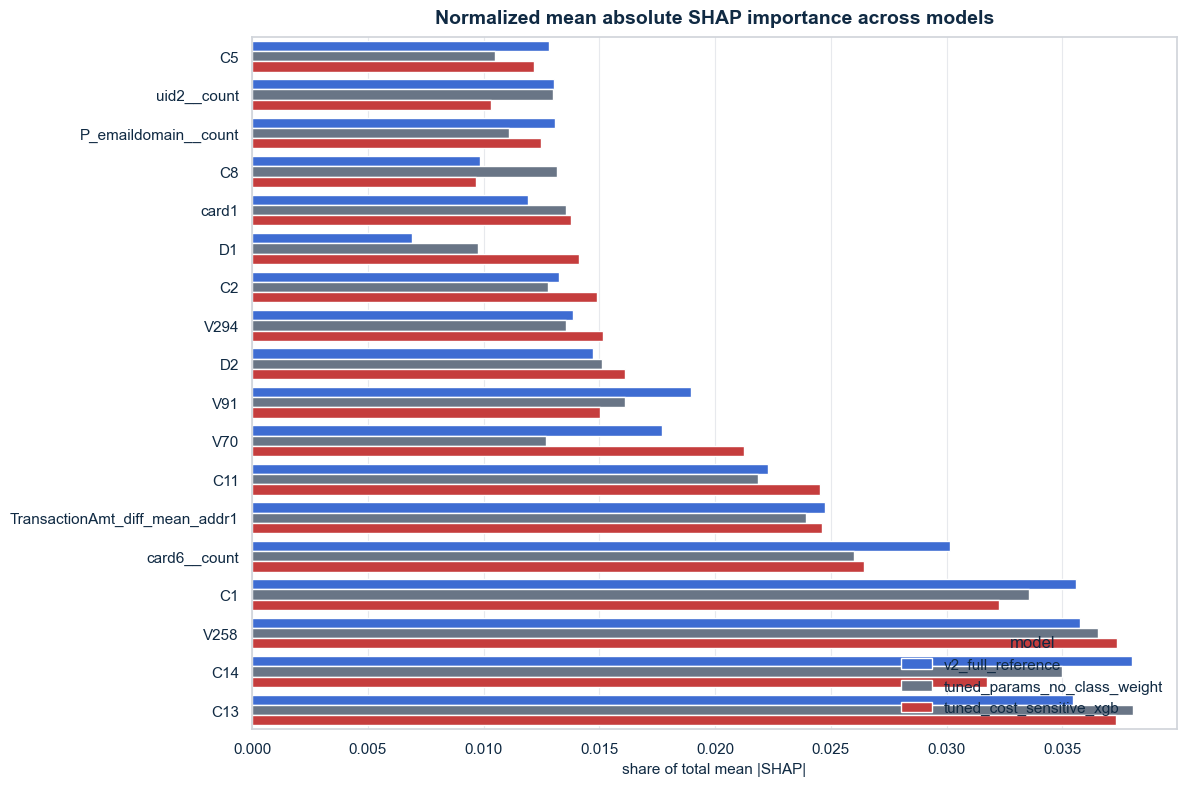

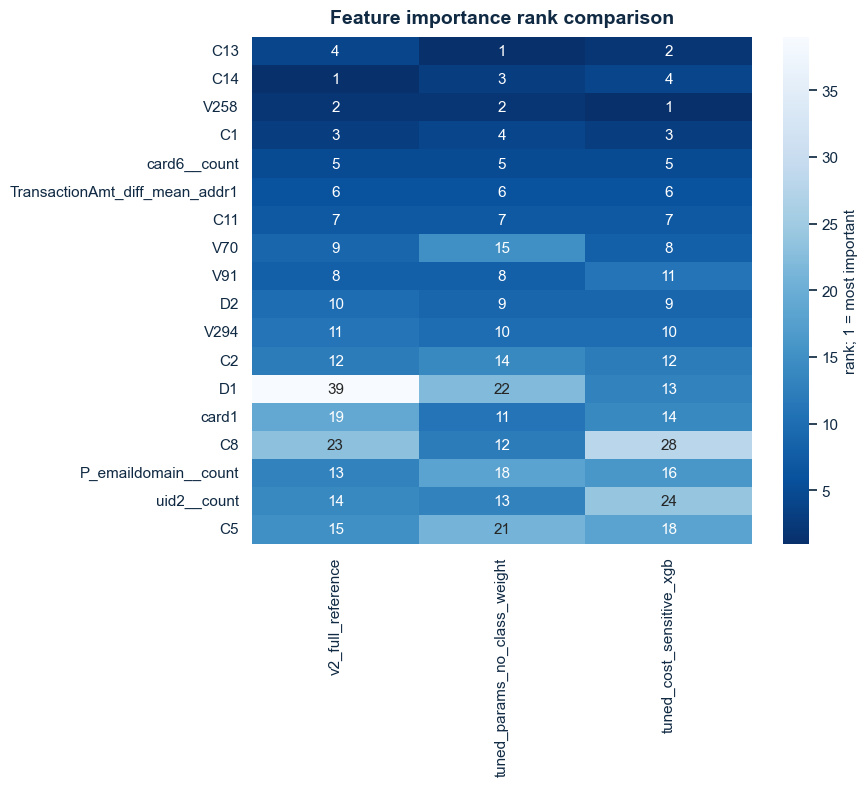

In [7]:
plot_features = (
    importance_long.groupby("feature")["normalized_importance"]
    .max()
    .sort_values(ascending=False)
    .head(18)
    .index
)
plot_frame = importance_long.loc[importance_long["feature"].isin(plot_features)].copy()
feature_order = (
    plot_frame.groupby("feature")["normalized_importance"]
    .max()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=plot_frame,
    x="normalized_importance",
    y="feature",
    hue="model",
    order=feature_order,
    hue_order=MODEL_ORDER,
    palette=MODEL_COLORS,
)
plt.title("Normalized mean absolute SHAP importance across models")
plt.xlabel("share of total mean |SHAP|")
plt.ylabel("")
plt.legend(title="model", loc="lower right")
plt.tight_layout()
plt.show()

rank_heatmap = (
    importance_long.loc[importance_long["feature"].isin(plot_features)]
    .pivot_table(index="feature", columns="model", values="rank", aggfunc="first")
    .loc[list(feature_order[::-1]), MODEL_ORDER]
)

plt.figure(figsize=(9, 8))
sns.heatmap(
    rank_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues_r",
    cbar_kws={"label": "rank; 1 = most important"},
)
plt.title("Feature importance rank comparison")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Feature Group Importance


model,feature_group,mean_abs_shap,group_share
tuned_cost_sensitive_xgb,raw_competition_signal,3.935792,0.622405
tuned_cost_sensitive_xgb,count_encoded_categorical,0.982349,0.155348
tuned_cost_sensitive_xgb,group_amount_deviation,0.500747,0.079188
tuned_cost_sensitive_xgb,raw_identity_or_card_signal,0.338714,0.053564
tuned_cost_sensitive_xgb,binary_match_flag,0.228057,0.036065
tuned_cost_sensitive_xgb,time,0.151863,0.024016
tuned_cost_sensitive_xgb,amount,0.099689,0.015765
tuned_cost_sensitive_xgb,missing_indicator,0.086308,0.013649
tuned_params_no_class_weight,raw_competition_signal,3.868340,0.628116
tuned_params_no_class_weight,count_encoded_categorical,0.964406,0.156594


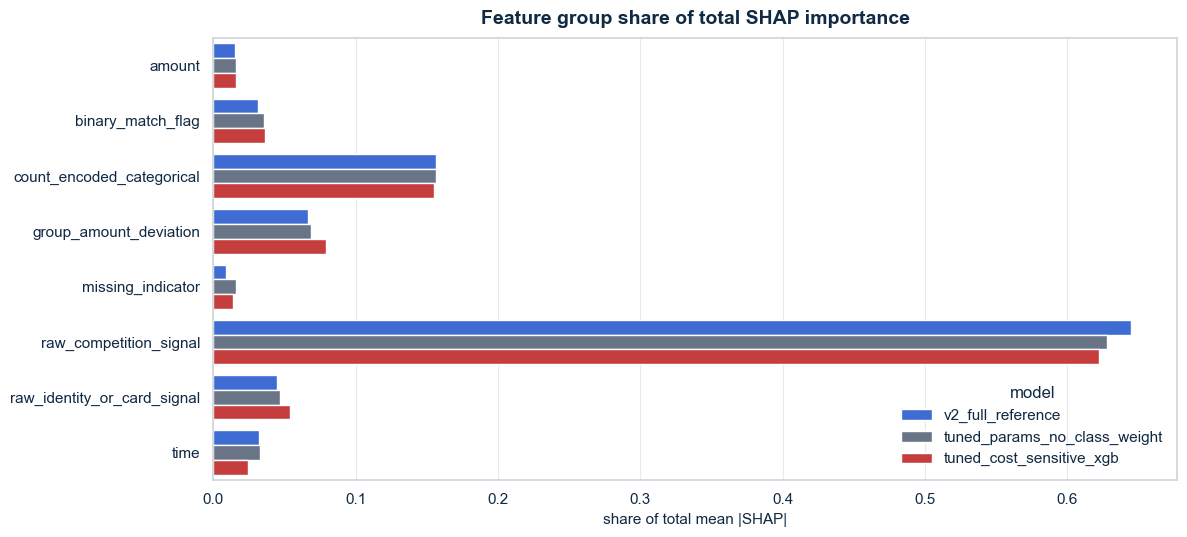

In [8]:
group_importance = (
    importance_long
    .groupby(["model", "feature_group"], as_index=False)["mean_abs_shap"]
    .sum()
)
group_importance["group_share"] = group_importance.groupby("model")["mean_abs_shap"].transform(lambda values: values / values.sum())

display(
    group_importance
    .sort_values(["model", "group_share"], ascending=[True, False])
    .style.hide(axis="index")
)

plt.figure(figsize=(12, 5.5))
sns.barplot(
    data=group_importance,
    x="group_share",
    y="feature_group",
    hue="model",
    hue_order=MODEL_ORDER,
    palette=MODEL_COLORS,
)
plt.title("Feature group share of total SHAP importance")
plt.xlabel("share of total mean |SHAP|")
plt.ylabel("")
plt.legend(title="model", loc="lower right")
plt.tight_layout()
plt.show()


## Direction Check For Top Features


In [9]:
direction_rows = []

for model_name in MODEL_ORDER:
    shap_matrix = shap_packs[model_name]["shap_matrix"]
    top_features = (
        importance_long.loc[importance_long["model"] == model_name]
        .nsmallest(10, "rank")["feature"]
        .tolist()
    )

    for feature in top_features:
        values = pd.to_numeric(x_shap[feature], errors="coerce")
        shap_values = pd.Series(shap_matrix[:, x_shap.columns.get_loc(feature)], index=x_shap.index)
        valid_mask = values.notna()
        values = values.loc[valid_mask]
        shap_values = shap_values.loc[valid_mask]

        if values.nunique(dropna=True) < 2:
            direction_delta = np.nan
            direction = "not enough variation"
        else:
            low_cut = values.quantile(0.25)
            high_cut = values.quantile(0.75)
            low_mean = shap_values.loc[values <= low_cut].mean()
            high_mean = shap_values.loc[values >= high_cut].mean()
            direction_delta = high_mean - low_mean
            direction = "higher value pushes fraud risk up" if direction_delta > 0 else "higher value pushes fraud risk down"

        direction_rows.append(
            {
                "model": model_name,
                "feature": feature,
                "feature_group": feature_group(feature),
                "rank": int(
                    importance_long.loc[
                        (importance_long["model"] == model_name)
                        & (importance_long["feature"] == feature),
                        "rank",
                    ].iloc[0]
                ),
                "high_minus_low_mean_shap": direction_delta,
                "direction_read": direction,
            }
        )

direction_summary = pd.DataFrame(direction_rows)
display(direction_summary.style.hide(axis="index"))


model,feature,feature_group,rank,high_minus_low_mean_shap,direction_read
v2_full_reference,C14,raw_competition_signal,1,-0.362605,higher value pushes fraud risk down
v2_full_reference,V258,raw_competition_signal,2,1.596942,higher value pushes fraud risk up
v2_full_reference,C1,raw_competition_signal,3,0.505547,higher value pushes fraud risk up
v2_full_reference,C13,raw_competition_signal,4,-0.562552,higher value pushes fraud risk down
v2_full_reference,card6__count,count_encoded_categorical,5,-0.388382,higher value pushes fraud risk down
v2_full_reference,TransactionAmt_diff_mean_addr1,group_amount_deviation,6,0.331751,higher value pushes fraud risk up
v2_full_reference,C11,raw_competition_signal,7,0.308393,higher value pushes fraud risk up
v2_full_reference,V91,raw_competition_signal,8,-0.290955,higher value pushes fraud risk down
v2_full_reference,V70,raw_competition_signal,9,-0.266695,higher value pushes fraud risk down
v2_full_reference,D2,raw_competition_signal,10,-0.411643,higher value pushes fraud risk down


## SHAP Summary Plots


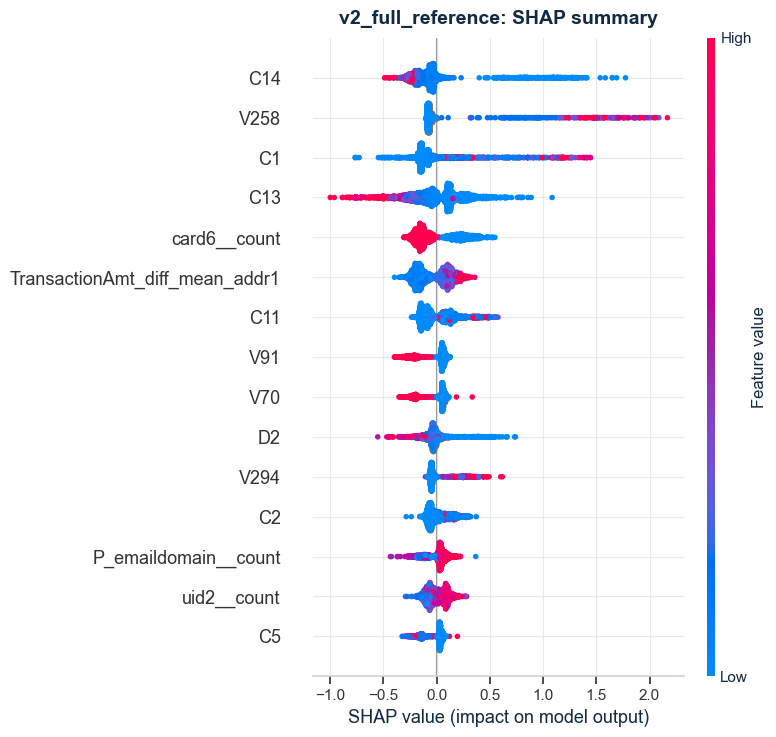

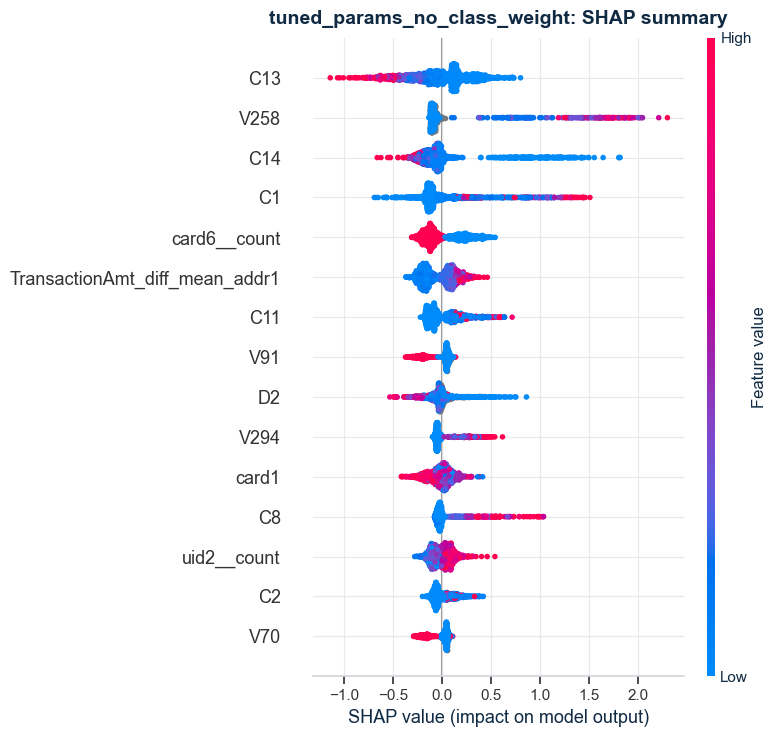

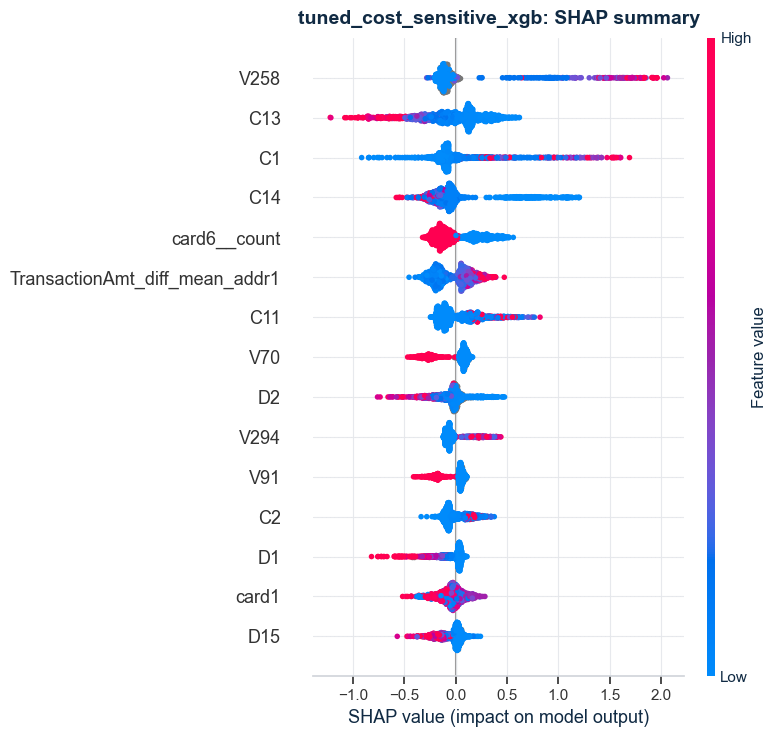

In [10]:
for model_name in MODEL_ORDER:
    shap.summary_plot(
        shap_packs[model_name]["shap_matrix"],
        x_shap,
        show=False,
        max_display=15,
        color_bar=True,
    )
    plt.title(f"{model_name}: SHAP summary")
    plt.tight_layout()
    plt.show()


## Compact Takeaways


In [11]:
best_model = model_metrics.iloc[0]["model"]
top5_by_model = (
    importance_long
    .sort_values(["model", "rank"])
    .groupby("model")
    .head(5)
    .groupby("model")["feature"]
    .apply(lambda features: ", ".join(features))
    .reset_index(name="top_5_features")
)

selected_vs_reference_overlap = overlap_summary.loc[
    (overlap_summary["model_a"] == "v2_full_reference")
    & (overlap_summary["model_b"] == "tuned_params_no_class_weight")
].iloc[0]

selected_vs_weighted_overlap = overlap_summary.loc[
    (overlap_summary["model_a"] == "tuned_params_no_class_weight")
    & (overlap_summary["model_b"] == "tuned_cost_sensitive_xgb")
].iloc[0]

compact_takeaways = pd.DataFrame(
    [
        {
            "question": "Best validation model in this comparison",
            "answer": best_model,
        },
        {
            "question": "Top-20 overlap: selected vs reference",
            "answer": f"{selected_vs_reference_overlap['top20_overlap_count']} shared features; Jaccard {selected_vs_reference_overlap['top20_jaccard']:.3f}",
        },
        {
            "question": "Top-20 overlap: selected vs weighted",
            "answer": f"{selected_vs_weighted_overlap['top20_overlap_count']} shared features; Jaccard {selected_vs_weighted_overlap['top20_jaccard']:.3f}",
        },
        {
            "question": "Interpretation",
            "answer": "Use this as model behavior evidence: tuning changes both performance and feature reliance; class weighting changes the score scale and some SHAP rankings, but did not beat the no-weight tuned model on validation.",
        },
    ]
)

display(top5_by_model.style.hide(axis="index"))
display(compact_takeaways.style.hide(axis="index"))

summary_payload = {
    "model_metrics": model_metrics.to_dict(orient="records"),
    "shap_sample": shap_sample_summary.to_dict(orient="records"),
    "top5_by_model": top5_by_model.to_dict(orient="records"),
    "top20_overlap": overlap_summary.to_dict(orient="records"),
    "rank_correlation": rank_correlation.reset_index().to_dict(orient="records"),
    "feature_group_importance": group_importance.to_dict(orient="records"),
    "compact_takeaways": compact_takeaways.to_dict(orient="records"),
}
OUTPUT_PATH.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")
print(f"Saved {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")


model,top_5_features
tuned_cost_sensitive_xgb,"V258, C13, C1, C14, card6__count"
tuned_params_no_class_weight,"C13, V258, C14, C1, card6__count"
v2_full_reference,"C14, V258, C1, C13, card6__count"


question,answer
Best validation model in this comparison,tuned_params_no_class_weight
Top-20 overlap: selected vs reference,17 shared features; Jaccard 0.739
Top-20 overlap: selected vs weighted,15 shared features; Jaccard 0.600
Interpretation,"Use this as model behavior evidence: tuning changes both performance and feature reliance; class weighting changes the score scale and some SHAP rankings, but did not beat the no-weight tuned model on validation."


Saved outputs/shap_model_comparison_summary.json
